# 01 — Synthetic healthcare-network data generation

This notebook generates and explains the fully synthetic dataset used across the
project. No real patient data is involved at any point: every table is produced
by a seeded simulation of a healthcare network, aggregated at clinic level.

**Why synthetic data?** A portfolio project cannot use protected health
information. Instead of toy data, we simulate the *operational structure* of a
real network — weekday profiles, seasonality, holidays, marketing pressure,
no-shows, cancellations and capacity limits — so the downstream forecasting and
staffing work faces realistic challenges.

## Simulation design

Demand is generated in the order a real clinic experiences it:

1. **Expected scheduled appointments** are driven by clinic size, specialty, a
   clinic-specific weekday profile, winter/summer seasonality with a
   clinic-specific phase, public holidays, a piecewise trend with random
   changepoints, and marketing pressure with adstock carryover and
   diminishing returns.
2. **A persistent AR(1) episode process** multiplies expected demand: flu
   waves and local events create multi-week deviations that no calendar
   feature explains. This is the component that bounds achievable forecast
   accuracy.
3. **Scheduled appointments** are drawn from a negative binomial distribution
   (variance above the mean), matching the overdispersion of real appointment
   counts.
4. **No-shows and same-day cancellations** remove a stochastic share of the
   schedule; the base no-show rate differs by clinic.
5. **Completed visits** are capped by the clinic's daily capacity, so demand
   spikes saturate instead of growing without bound.

Each synthetic feature exists for a downstream reason:

| Feature | Why it exists |
|---|---|
| Regions | Enables regional aggregation and hierarchical reconciliation |
| Specialties | Different base demand and weekend behaviour (urgent care opens weekends) |
| Opening days | Zero-demand Sundays/holidays test models against structural zeros |
| Public holidays | Calendar effects that models must capture as exogenous inputs |
| Marketing channels with adstock | Exogenous drivers with carryover and diminishing returns - not trivially linear |
| Demand episodes (AR(1)) | Persistent unforecastable waves that set an honest accuracy ceiling |
| Trend changepoints | Growth is piecewise, not linear - tests local trend adaptation |
| Overdispersed counts | Negative binomial noise, variance above Poisson |
| No-show rate and cancellations | Secondary forecasting targets; schedule vs realised demand |
| Capacity limits | Saturation effects and censored peak demand |
| Staffing by role | Baseline for staffing-gap and cost analysis |

The generator is configurable: `seasonality_strength`, `marketing_strength`
and `noise_level` scale their respective effects (0 disables them), which is
useful for testing models against simpler or harsher data.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (11, 4)

In [2]:
from clinic_forecast.data import SyntheticDataConfig, generate_network_data

config = SyntheticDataConfig(
    start_date="2022-01-01",
    end_date="2025-12-31",
    n_clinics=12,
    random_seed=42,
)

network = generate_network_data(config)
usage, metadata = network.usage, network.metadata
marketing, staffing = network.marketing, network.staffing

for name, frame in [
    ("usage", usage), ("metadata", metadata),
    ("marketing", marketing), ("staffing", staffing),
]:
    print(f"{name:10s} {frame.shape}")
usage.head()

usage      (17532, 32)
metadata   (12, 9)
marketing  (17532, 8)
staffing   (17532, 5)


,date,day_of_week,month,week_of_year,is_weekend,is_monday,is_winter,is_summer,is_holiday,yearly_season,clinic_id,campaign_active,spend_search,spend_social,spend_email,spend_local,marketing_spend,scheduled_appointments,no_show_count,same_day_cancellations,no_show_rate,visits,is_open,capacity_utilization,region,clinic_size,specialty,daily_capacity,base_clinicians,base_nurses,base_frontdesk,weekend_open
0,2022-01-01,5,1,52,1,0,1,0,1,0.017202,CLINIC_001,0,91.802874,50.859325,83.535740,49.608578,275.806516,0,0,0,0.041635,0,0,0.000000,north,medium,primary_care,131,7,9,4,0
1,2022-01-02,6,1,52,1,0,1,0,0,0.034398,CLINIC_001,0,86.282006,18.259836,43.630329,6.766152,154.938324,0,0,0,0.062005,0,0,0.000000,north,medium,primary_care,131,7,9,4,0
2,2022-01-03,0,1,1,0,1,1,0,0,0.051584,CLINIC_001,0,133.979496,84.715394,63.865781,63.424127,345.984799,154,11,5,0.063909,131,1,1.000000,north,medium,primary_care,131,7,9,4,0
3,2022-01-04,1,1,1,0,0,1,0,0,0.068755,CLINIC_001,0,104.380411,43.518761,51.814647,53.543354,253.257172,101,2,3,0.043905,96,1,0.732824,north,medium,primary_care,131,7,9,4,0
4,2022-01-05,2,1,1,0,0,1,0,0,0.085906,CLINIC_001,0,102.205391,32.397962,49.222075,41.811541,225.636969,112,13,8,0.067146,91,1,0.694656,north,medium,primary_care,131,7,9,4,0


## Clinic metadata

Twelve clinics across four regions and five specialties. `daily_capacity` caps
completed visits; the `base_*` columns are the staffing baseline used later for
gap analysis; `weekend_open` is 1 only for urgent care.

In [3]:
metadata

,clinic_id,region,clinic_size,specialty,daily_capacity,base_clinicians,base_nurses,base_frontdesk,weekend_open
0,CLINIC_001,north,medium,primary_care,131,7,9,4,0
1,CLINIC_002,south,large,urgent_care,227,11,14,6,1
2,CLINIC_003,east,small,cardiology,69,4,5,2,0
3,CLINIC_004,west,medium,orthopedics,137,7,9,4,0
4,CLINIC_005,north,small,pediatrics,73,4,5,2,0
5,CLINIC_006,south,medium,primary_care,146,7,9,4,0
6,CLINIC_007,east,medium,urgent_care,149,7,9,4,1
7,CLINIC_008,west,medium,cardiology,133,7,9,4,0
8,CLINIC_009,north,medium,orthopedics,132,7,9,4,0
9,CLINIC_010,south,large,pediatrics,219,11,14,6,0


## Network demand over time

The network total shows the structural signal models will need to learn:
weekly cycles (the dense band), winter peaks, holiday dips and mild growth.

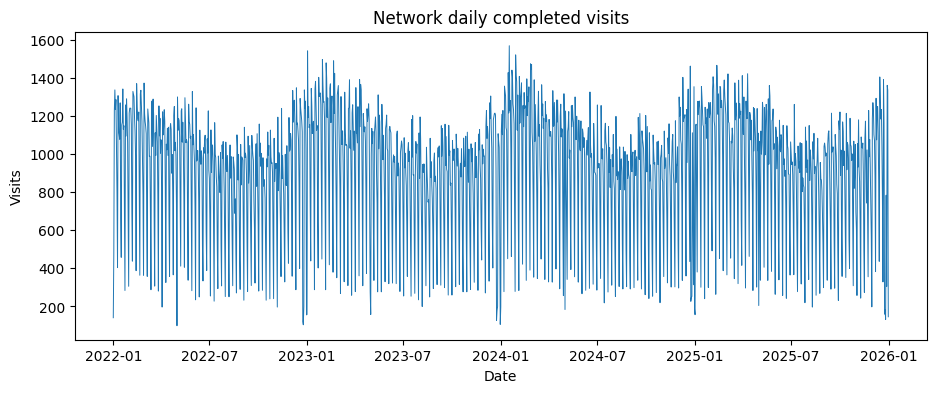

In [4]:
network_daily = usage.groupby("date", as_index=False)["visits"].sum()

fig, ax = plt.subplots()
ax.plot(network_daily["date"], network_daily["visits"], linewidth=0.7)
ax.set_title("Network daily completed visits")
ax.set_xlabel("Date")
ax.set_ylabel("Visits")
plt.show()

## One clinic up close: opening days and holidays

A 10-week window of a weekday-only clinic. Sundays and public holidays show
structural zeros — these are *closures*, not low demand, and models must not
smooth over them.

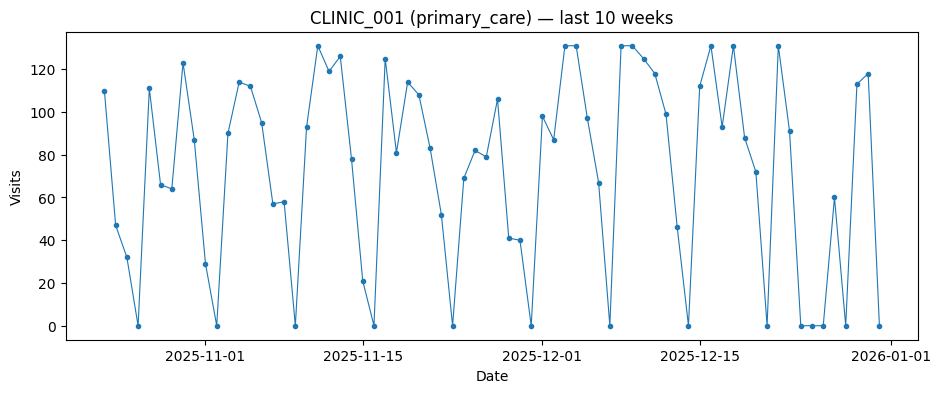

Share of clinics open by day of week (0=Mon):
dow
0    0.99
1    0.99
2    0.98
3    0.99
4    1.00
5    0.99
6    0.25
Name: is_open, dtype: float64


In [5]:
clinic_sample = usage[usage["clinic_id"] == "CLINIC_001"].tail(70)

fig, ax = plt.subplots()
ax.plot(clinic_sample["date"], clinic_sample["visits"], marker="o", markersize=3, linewidth=0.8)
ax.set_title(f"CLINIC_001 ({clinic_sample['specialty'].iloc[0]}) — last 10 weeks")
ax.set_xlabel("Date")
ax.set_ylabel("Visits")
plt.show()

weekday_open_share = (
    usage.assign(dow=pd.to_datetime(usage["date"]).dt.dayofweek)
    .groupby("dow")["is_open"].mean().round(2)
)
print("Share of clinics open by day of week (0=Mon):")
print(weekday_open_share)

## Scheduled vs realised demand

Scheduled appointments decompose into completed visits, no-shows and same-day
cancellations. Forecasting *visits* alone hides the fact that staffing must be
planned against the schedule, while revenue follows completed visits.

In [6]:
attrition = usage[usage["is_open"] == 1][
    ["scheduled_appointments", "visits", "no_show_count", "same_day_cancellations"]
].sum()
print(attrition)
no_show_share = attrition["no_show_count"] / attrition["scheduled_appointments"]
cancel_share = attrition["same_day_cancellations"] / attrition["scheduled_appointments"]
print(f"\nNo-show share of schedule:      {no_show_share:.1%}")
print(f"Cancellation share of schedule: {cancel_share:.1%}")

scheduled_appointments    1530747
visits                    1326176
no_show_count              131170
same_day_cancellations      48985
dtype: int64

No-show share of schedule:      8.6%
Cancellation share of schedule: 3.2%


## Marketing channels

Spend is split across search, social, email and local campaigns. Campaign
bursts (January and the autumn enrolment season) lift demand through a small
multiplicative effect — enough for models with exogenous inputs to exploit,
not so strong that it dominates the seasonal structure.

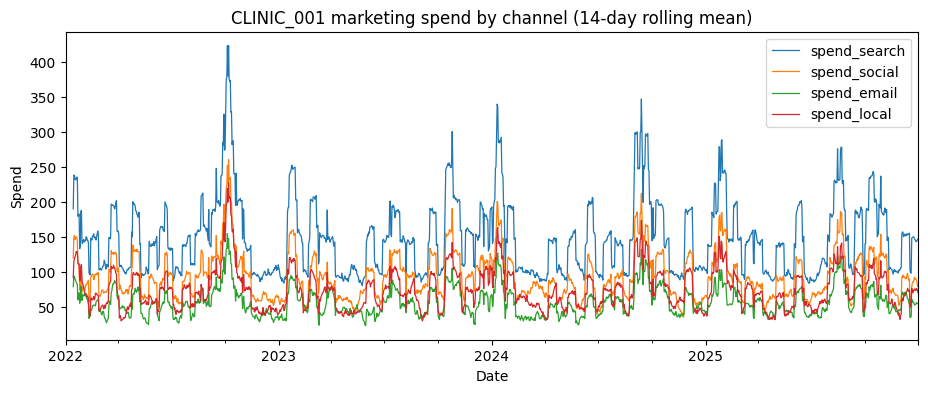

In [7]:
clinic_marketing = marketing[marketing["clinic_id"] == "CLINIC_001"].set_index("date")
channel_cols = ["spend_search", "spend_social", "spend_email", "spend_local"]

fig, ax = plt.subplots()
clinic_marketing[channel_cols].rolling(14).mean().plot(ax=ax, linewidth=0.9)
ax.set_title("CLINIC_001 marketing spend by channel (14-day rolling mean)")
ax.set_xlabel("Date")
ax.set_ylabel("Spend")
plt.show()

## Tunable generation strengths

`seasonality_strength=0` produces a flat weekday profile — handy for verifying
that a model's seasonal terms are actually doing work. `noise_level` and
`marketing_strength` can be tuned the same way.

In [8]:
flat = generate_network_data(
    SyntheticDataConfig(start_date="2024-01-01", end_date="2024-12-31",
                        n_clinics=6, seasonality_strength=0.0)
).usage

def weekday_profile(frame: pd.DataFrame) -> pd.Series:
    open_rows = frame[frame["is_open"] == 1]
    dow = pd.to_datetime(open_rows["date"]).dt.dayofweek
    return open_rows.groupby(dow)["visits"].mean()

profile = pd.DataFrame({
    "default": weekday_profile(usage),
    "seasonality_strength=0": weekday_profile(flat),
})
profile.index.name = "day_of_week"
profile.round(1)

,default,seasonality_strength=0
day_of_week,,
0,99.1,69.0
1,90.5,69.9
2,91.3,70.6
3,88.6,71.3
4,83.6,70.1
5,56.2,72.0
6,104.7,161.6


## Validate and save the contract files

The four tables are checked against the data contracts in
`clinic_forecast.contracts` and written to `data/processed/`. Downstream
notebooks read these files instead of regenerating data.

In [9]:
from clinic_forecast.contracts import (
    validate_clinic_metadata,
    validate_clinic_usage,
    validate_marketing,
    validate_staffing_daily,
)

validate_clinic_usage(usage)
validate_clinic_metadata(metadata)
validate_marketing(marketing)
validate_staffing_daily(staffing)

output_dir = PROJECT_ROOT / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

usage.to_csv(output_dir / "clinic_daily_usage.csv", index=False)
metadata.to_csv(output_dir / "clinic_metadata.csv", index=False)
marketing.to_csv(output_dir / "marketing_daily.csv", index=False)
staffing.to_csv(output_dir / "staffing_daily.csv", index=False)

print(f"Saved 4 contract files to {output_dir}")

Saved 4 contract files to C:\Users\diogo\work_code\clinic_forecasting_platform\data\processed


## Insights

- The dataset reproduces the operational structure that makes healthcare
  demand forecasting hard: strong weekly cycles, structural zeros from
  closures, seasonal peaks, marketing-driven bumps and capacity saturation.
- Scheduled and realised demand differ by roughly the no-show plus
  cancellation share — staffing decisions later in the project must choose
  which target to plan against.
- Everything is reproducible: the same `SyntheticDataConfig` always produces
  byte-identical CSVs, which the test suite asserts.

**Next:** notebook 02 explores these patterns and assesses forecastability.